In [1]:
# ============================================================
# Library Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

%matplotlib inline
print("Libraries loaded successfully.")

Libraries loaded successfully.


# Jigsaw Toxic Comment Classification - Exploratory Data Analysis (v2)

This notebook provides a comprehensive exploratory data analysis of the Jigsaw Toxic Comment dataset.

**Dataset columns:**
- `id` — Unique identifier for each comment
- `comment_text` — The raw comment text
- `toxic` — Binary label (1 = toxic)
- `severe_toxic` — Binary label (1 = severely toxic)
- `obscene` — Binary label (1 = obscene)
- `threat` — Binary label (1 = threatening)
- `insult` — Binary label (1 = insulting)
- `identity_hate` — Binary label (1 = identity-based hate)

**Sections covered:**
1. Data Loading & Initial Inspection
2. Missing Values & Duplicates
3. Feature Engineering
4. Target Label Distribution & Class Imbalance
5. Label Correlation & Co-occurrence
6. Text Length Analysis (Histograms, Boxplots, Violin Plots)
7. Writing Style Analysis
8. Word Frequency & Bad Word Analysis
9. Outlier Detection
10. Label Inconsistency Analysis
11. Conclusions

In [2]:
# ============================================================
# Data Loading - Read all parquet files and concatenate
# ============================================================
import glob

parquet_files = sorted(glob.glob('../data/*.parquet'))
print(f"Found {len(parquet_files)} parquet file(s): {parquet_files}")

data_frames = [pd.read_parquet(file, engine='fastparquet') for file in parquet_files]
df = pd.concat(data_frames, ignore_index=True) if data_frames else None

if df is None:
    raise FileNotFoundError("No .parquet files found in '../data/' directory.")

print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")

Found 10 parquet file(s): ['../data/dataset_part_1.parquet', '../data/dataset_part_10.parquet', '../data/dataset_part_2.parquet', '../data/dataset_part_3.parquet', '../data/dataset_part_4.parquet', '../data/dataset_part_5.parquet', '../data/dataset_part_6.parquet', '../data/dataset_part_7.parquet', '../data/dataset_part_8.parquet', '../data/dataset_part_9.parquet']
Dataset loaded successfully with 223,549 rows and 8 columns.


In [3]:
# ============================================================
# Load bad words dictionary for later analysis
# ============================================================
with open('../data/bad-words.txt') as file:
    bad_words = set(line.strip() for line in file.readlines())

print(f"Loaded {len(bad_words)} bad words from dictionary.")

Loaded 1383 bad words from dictionary.


---
## 1. Initial Data Inspection

First look at the dataset: shape, data types, sample rows, and basic statistics.

In [4]:
# Dataset shape and column types
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Column types:")
print(df.dtypes)
print("\n" + "=" * 60)
print("First 5 rows:")
df.head()

Shape: 223,549 rows x 8 columns

Column types:
id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

First 5 rows:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
# Descriptive statistics for all numeric (label) columns
df.describe().round(4)

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,223549.0000,223549.0000,223549.0000,223549.0000,223549.0000,223549.0000
mean,0.0957,0.0088,0.0543,0.0031,0.0506,0.0095
std,0.2941,0.0933,0.2266,0.0554,0.2191,0.0969
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## 2. Missing Values & Duplicate Detection

Check data quality: null values in every column and duplicate rows/comments.

In [6]:
# ============================================================
# 2a. Missing Values Check
# ============================================================
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print("Missing Values Report:")
print(missing_report)
print(f"\nTotal missing cells: {missing.sum()}")

# ============================================================
# 2b. Duplicate Detection
# ============================================================
dup_rows = df.duplicated().sum()
dup_ids = df['id'].duplicated().sum()
dup_comments = df['comment_text'].duplicated().sum()

print(f"\n{'=' * 60}")
print(f"Exact duplicate rows:       {dup_rows:,}")
print(f"Duplicate IDs:              {dup_ids:,}")
print(f"Duplicate comment texts:    {dup_comments:,}")

if dup_comments > 0:
    print(f"\nSample duplicated comments:")
    dup_texts = df[df['comment_text'].duplicated(keep=False)].sort_values('comment_text')
    print(dup_texts[['id', 'comment_text', 'toxic']].head(6))

Missing Values Report:
               Missing Count  Missing %
id                         0        0.0
comment_text               0        0.0
toxic                      0        0.0
severe_toxic               0        0.0
obscene                    0        0.0
threat                     0        0.0
insult                     0        0.0
identity_hate              0        0.0

Total missing cells: 0

Exact duplicate rows:       0
Duplicate IDs:              0
Duplicate comment texts:    0


---
## 3. Feature Engineering

Create derived columns from `comment_text` that will be useful for analysis:
- **char_length**: Total number of characters
- **word_count**: Total number of words
- **avg_word_length**: Average characters per word (writing complexity proxy)
- **uppercase_ratio**: Proportion of uppercase characters (shouting indicator)
- **exclamation_count**: Number of exclamation marks (aggression signal)
- **question_count**: Number of question marks
- **unique_word_ratio**: Ratio of unique words to total words (vocabulary diversity)
- **bad_word_count**: Count of words matching the bad-words dictionary
- **num_labels**: How many toxicity labels are assigned (0-6)

In [7]:
# ============================================================
# 3. Feature Engineering - Create derived text features
# ============================================================

# Define the 6 target label columns
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Character length
df['char_length'] = df['comment_text'].str.len()

# Word count
df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))

# Average word length (characters per word)
df['avg_word_length'] = df['char_length'] / (df['word_count'].replace(0, 1))

# Uppercase ratio — proportion of uppercase letters (caps-lock = shouting)
df['uppercase_ratio'] = df['comment_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

# Exclamation marks count
df['exclamation_count'] = df['comment_text'].str.count('!')

# Question marks count
df['question_count'] = df['comment_text'].str.count(r'\?')

# Unique word ratio (vocabulary diversity)
def unique_word_ratio(text):
    words = str(text).lower().split()
    return len(set(words)) / max(len(words), 1)

df['unique_word_ratio'] = df['comment_text'].apply(unique_word_ratio)

# Bad word count — how many words in the comment match the bad-words dictionary
def count_bad_words(text):
    words = re.findall(r"[a-zA-Z']+", str(text).lower())
    return sum(1 for w in words if w in bad_words)

df['bad_word_count'] = df['comment_text'].apply(count_bad_words)

# Number of toxicity labels assigned to each comment (0-6)
df['num_labels'] = df[label_cols].sum(axis=1).astype(int)

print("New columns created:")
print(df[['char_length', 'word_count', 'avg_word_length', 'uppercase_ratio',
          'exclamation_count', 'question_count', 'unique_word_ratio',
          'bad_word_count', 'num_labels']].describe().round(3))

New columns created:
       char_length  word_count  avg_word_length  uppercase_ratio  \
count   223549.000  223549.000       223549.000       223549.000   
mean       391.013      66.517            6.003            0.052   
std        592.863      99.475            7.579            0.096   
min          1.000       1.000            1.000            0.000   
25%         93.000      16.000            5.333            0.020   
50%        203.000      35.000            5.722            0.031   
75%        431.000      74.000            6.143            0.048   
max       5000.000    2321.000         1656.333            1.000   

       exclamation_count  question_count  unique_word_ratio  bad_word_count  \
count         223549.000      223549.000         223549.000      223549.000   
mean               0.764           0.442              0.843           1.084   
std               27.567           1.608              0.134          12.952   
min                0.000           0.000          

---
## 4. Target Label Distribution & Class Imbalance

Analyze the distribution of each toxicity label. This is a **multi-label** classification problem, so a single comment can have multiple labels simultaneously.

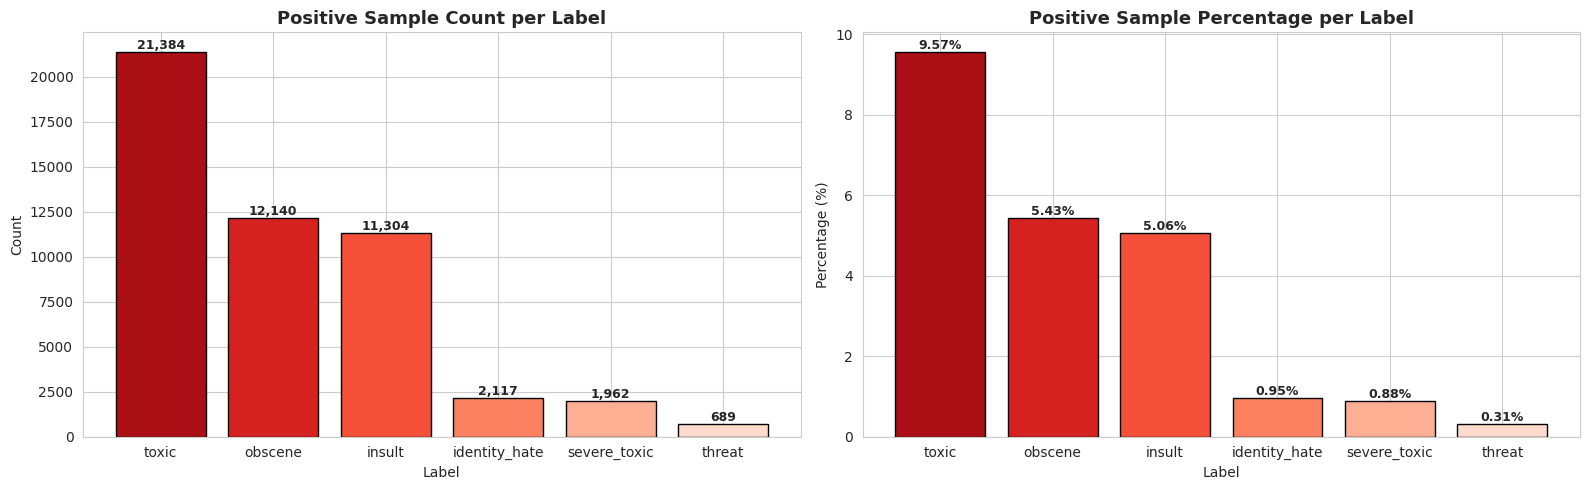


Clean comments (no labels):    201,081 (89.95%)
Flagged comments (>=1 label):  22,468 (10.05%)


In [8]:
# ============================================================
# 4a. Count of positive (=1) samples per label — Bar Chart
# ============================================================

label_counts = df[label_cols].sum().sort_values(ascending=False)
label_pcts = (label_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — absolute counts
colors = sns.color_palette('Reds_r', len(label_cols))
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Positive Sample Count per Label', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Label')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bar chart — percentage
bars2 = axes[1].bar(label_pcts.index, label_pcts.values, color=colors, edgecolor='black')
axes[1].set_title('Positive Sample Percentage per Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Label')
for bar, val in zip(bars2, label_pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f'{val}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print clean vs classified breakdown
clean_count = (df['num_labels'] == 0).sum()
flagged_count = (df['num_labels'] > 0).sum()
print(f"\nClean comments (no labels):    {clean_count:,} ({clean_count/len(df)*100:.2f}%)")
print(f"Flagged comments (>=1 label):  {flagged_count:,} ({flagged_count/len(df)*100:.2f}%)")

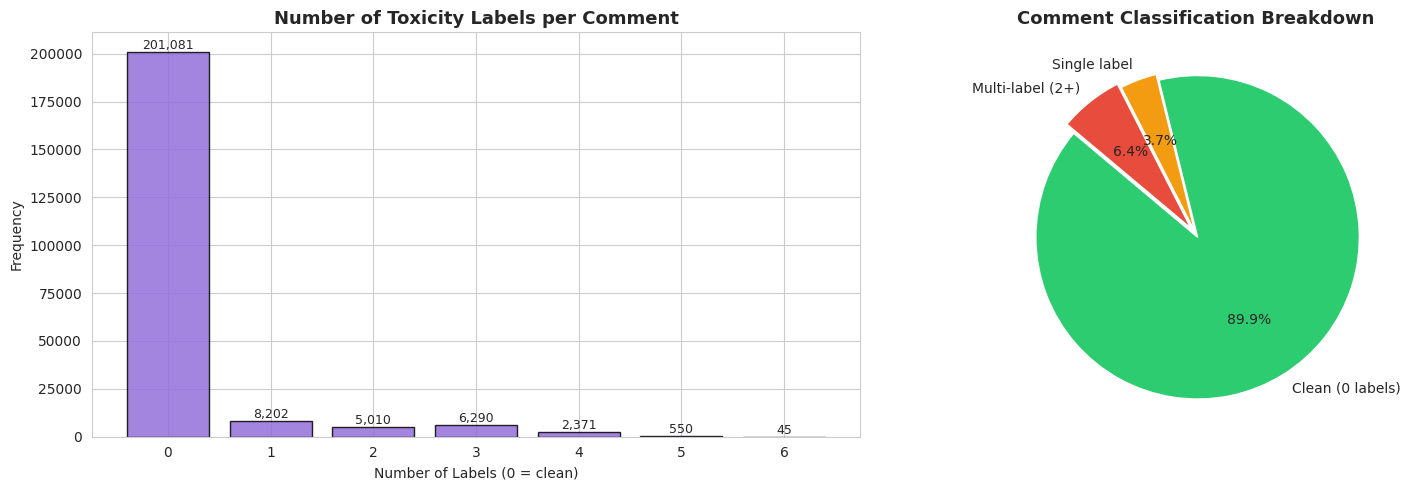

Clean: 201,081 | Single-label: 8,202 | Multi-label: 14,266


In [9]:
# ============================================================
# 4b. Multi-Label Distribution — How many labels per comment?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of num_labels
num_label_dist = df['num_labels'].value_counts().sort_index()
bars = axes[0].bar(num_label_dist.index, num_label_dist.values,
                   color='mediumpurple', edgecolor='black', alpha=0.85)
axes[0].set_title('Number of Toxicity Labels per Comment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Labels (0 = clean)')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(0, 7))
for bar, val in zip(bars, num_label_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:,}',
                 ha='center', va='bottom', fontsize=9)

# Pie chart — clean vs single vs multi-label
clean = (df['num_labels'] == 0).sum()
single = (df['num_labels'] == 1).sum()
multi = (df['num_labels'] >= 2).sum()
pie_labels = ['Clean (0 labels)', 'Single label', 'Multi-label (2+)']
pie_sizes = [clean, single, multi]
pie_colors = ['#2ecc71', '#f39c12', '#e74c3c']
explode = (0.02, 0.02, 0.05)

axes[1].pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', colors=pie_colors,
            explode=explode, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Comment Classification Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Clean: {clean:,} | Single-label: {single:,} | Multi-label: {multi:,}")

---
## 5. Label Correlation & Co-occurrence

How do the 6 toxicity labels relate to each other? A correlation heatmap shows linear relationships. The co-occurrence matrix shows how often pairs of labels appear together.

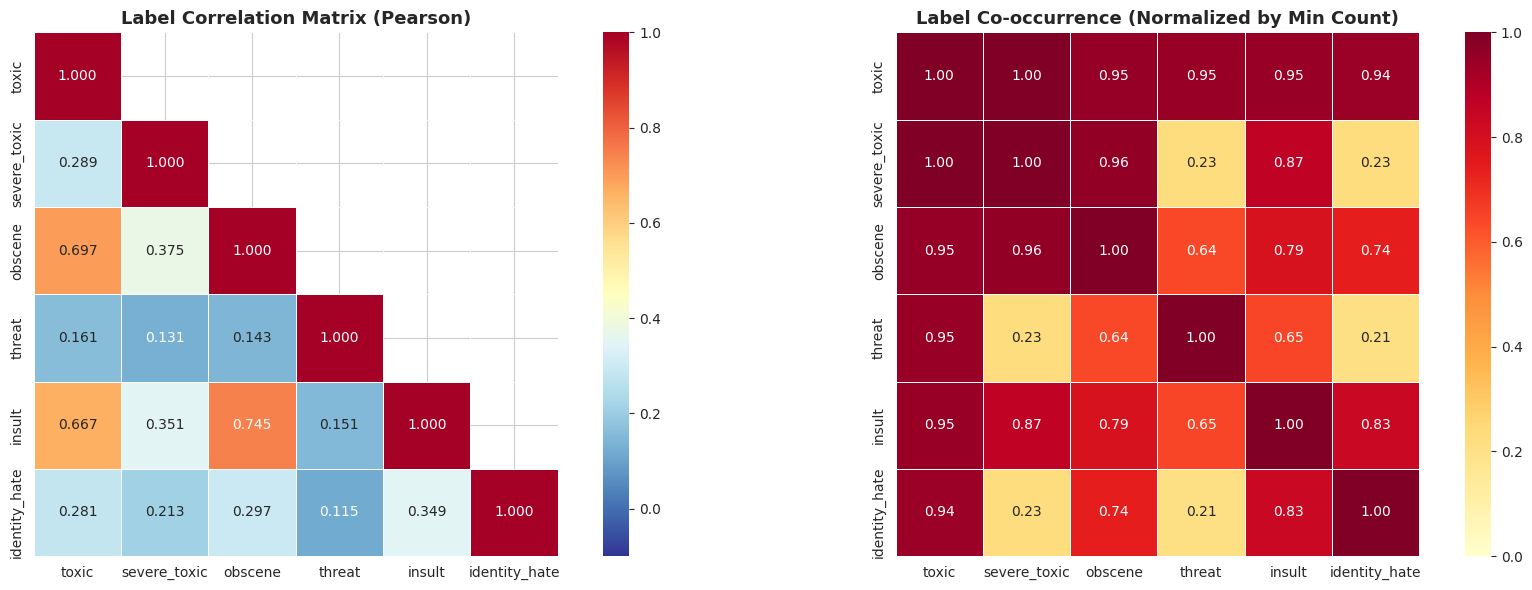

Interpretation: Values close to 1.0 mean that when the rarer label is present,
the other label almost always appears too.


In [10]:
# ============================================================
# 5a. Correlation Heatmap between Labels
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pearson correlation
corr_matrix = df[label_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            mask=mask, vmin=-0.1, vmax=1, linewidths=0.5,
            ax=axes[0], square=True)
axes[0].set_title('Label Correlation Matrix (Pearson)', fontsize=13, fontweight='bold')

# ============================================================
# 5b. Co-occurrence Matrix — actual counts of label pairs
# ============================================================
cooccurrence = df[label_cols].T.dot(df[label_cols])

# Normalize by the minimum of the two label counts for interpretability
for i in label_cols:
    for j in label_cols:
        min_count = min(df[i].sum(), df[j].sum())
        if min_count > 0 and i != j:
            cooccurrence.loc[i, j] = cooccurrence.loc[i, j] / min_count
        elif i == j:
            cooccurrence.loc[i, j] = 1.0

sns.heatmap(cooccurrence, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], square=True, vmin=0, vmax=1)
axes[1].set_title('Label Co-occurrence (Normalized by Min Count)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Interpretation: Values close to 1.0 mean that when the rarer label is present,")
print("the other label almost always appears too.")

---
## 6. Text Length Analysis

Compare how text length (characters and words) differs between toxic and non-toxic comments using histograms, boxplots, and violin plots.

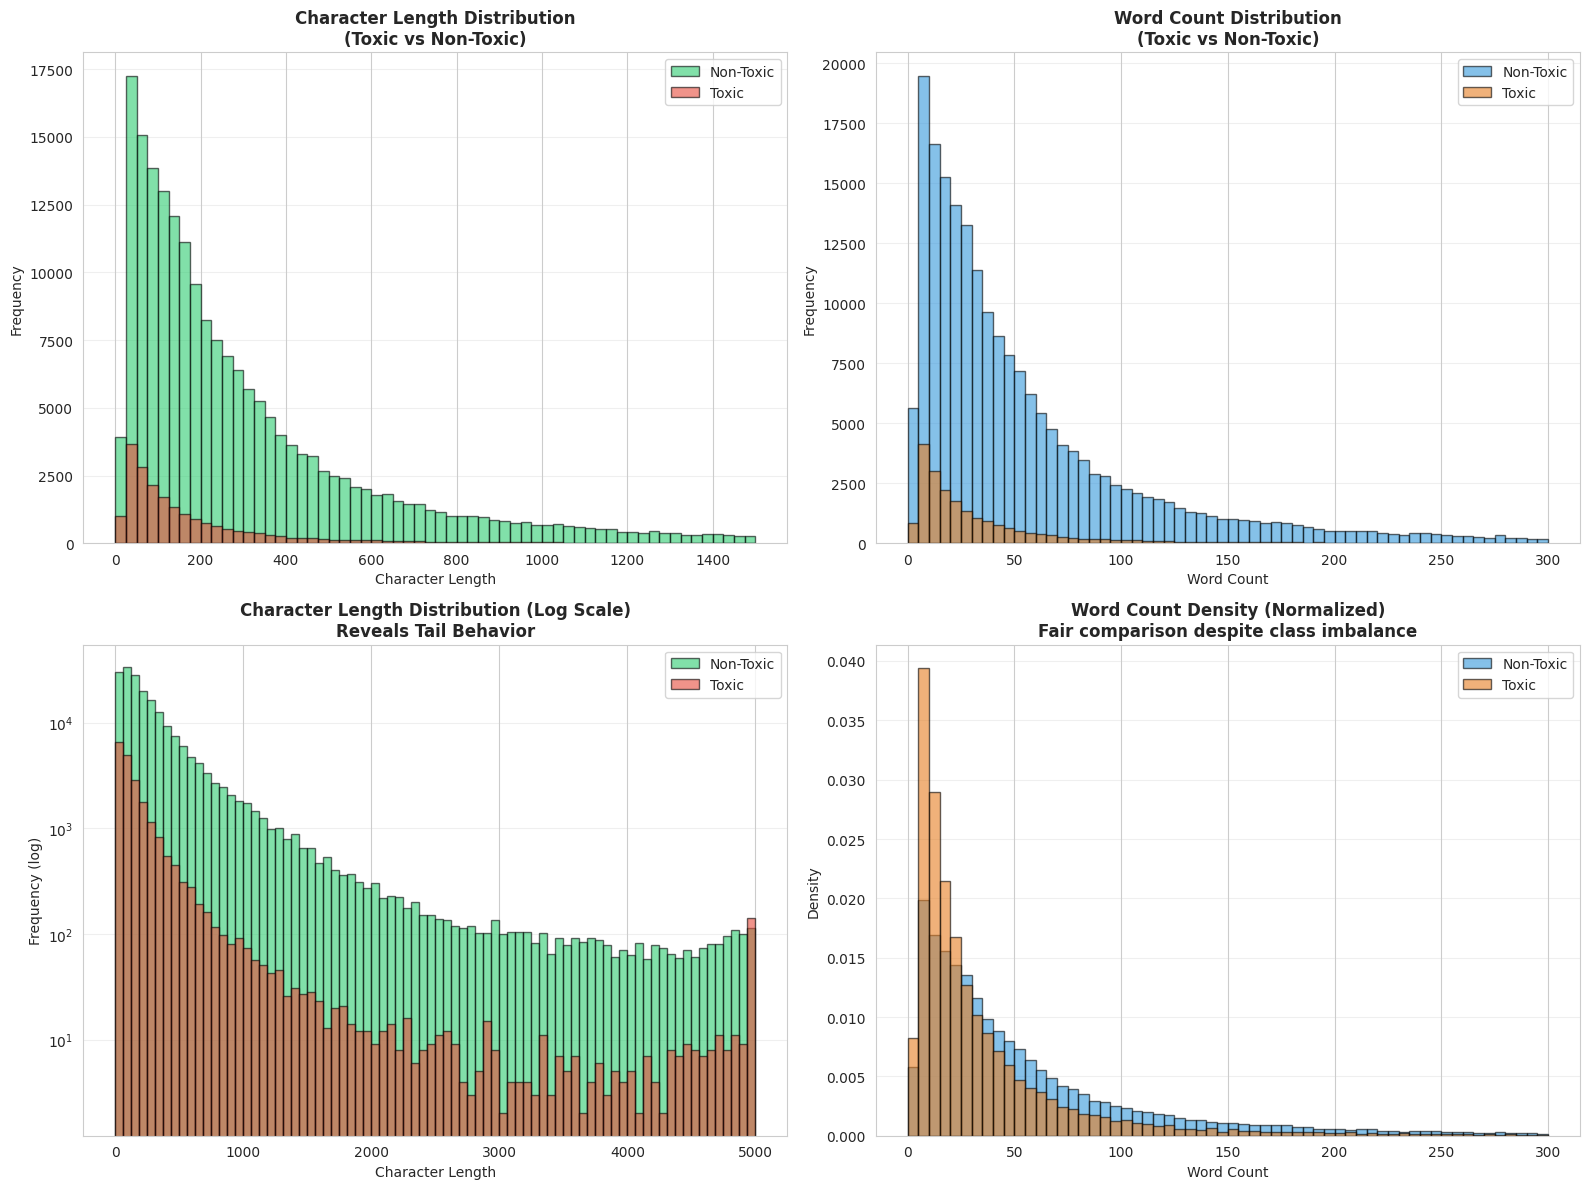

Character Length Summary:
          count   mean    std  min    25%    50%    75%     max
toxic                                                          
0      202165.0  402.7  589.4  1.0  100.0  215.0  450.0  5000.0
1       21384.0  280.6  613.6  3.0   55.0  115.0  250.0  5000.0

Word Count Summary:
          count  mean    std  min   25%   50%   75%     max
toxic                                                      
0      202165.0  68.4   98.6  1.0  17.0  37.0  77.0  1990.0
1       21384.0  48.6  105.4  1.0  10.0  21.0  45.0  2321.0


In [11]:
# ============================================================
# 6a. Overlapping Histograms — Character Length & Word Count
#     by Toxic vs Non-Toxic
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

toxic_mask = df['toxic'] == 1
non_toxic_mask = df['toxic'] == 0

# --- Top-left: Character Length Histogram ---
axes[0, 0].hist(df.loc[non_toxic_mask, 'char_length'], bins=60, alpha=0.6,
                label='Non-Toxic', color='#2ecc71', edgecolor='black', range=(0, 1500))
axes[0, 0].hist(df.loc[toxic_mask, 'char_length'], bins=60, alpha=0.6,
                label='Toxic', color='#e74c3c', edgecolor='black', range=(0, 1500))
axes[0, 0].set_title('Character Length Distribution\n(Toxic vs Non-Toxic)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# --- Top-right: Word Count Histogram ---
axes[0, 1].hist(df.loc[non_toxic_mask, 'word_count'], bins=60, alpha=0.6,
                label='Non-Toxic', color='#3498db', edgecolor='black', range=(0, 300))
axes[0, 1].hist(df.loc[toxic_mask, 'word_count'], bins=60, alpha=0.6,
                label='Toxic', color='#e67e22', edgecolor='black', range=(0, 300))
axes[0, 1].set_title('Word Count Distribution\n(Toxic vs Non-Toxic)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# --- Bottom-left: Log-scale Character Length (to see tail behavior) ---
axes[1, 0].hist(df.loc[non_toxic_mask, 'char_length'], bins=80, alpha=0.6,
                label='Non-Toxic', color='#2ecc71', edgecolor='black')
axes[1, 0].hist(df.loc[toxic_mask, 'char_length'], bins=80, alpha=0.6,
                label='Toxic', color='#e74c3c', edgecolor='black')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Character Length Distribution (Log Scale)\nReveals Tail Behavior', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Character Length')
axes[1, 0].set_ylabel('Frequency (log)')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# --- Bottom-right: Normalized (density) Word Count ---
axes[1, 1].hist(df.loc[non_toxic_mask, 'word_count'], bins=60, alpha=0.6,
                label='Non-Toxic', color='#3498db', edgecolor='black',
                range=(0, 300), density=True)
axes[1, 1].hist(df.loc[toxic_mask, 'word_count'], bins=60, alpha=0.6,
                label='Toxic', color='#e67e22', edgecolor='black',
                range=(0, 300), density=True)
axes[1, 1].set_title('Word Count Density (Normalized)\nFair comparison despite class imbalance', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
print("Character Length Summary:")
print(df.groupby('toxic')['char_length'].describe().round(1))
print("\nWord Count Summary:")
print(df.groupby('toxic')['word_count'].describe().round(1))

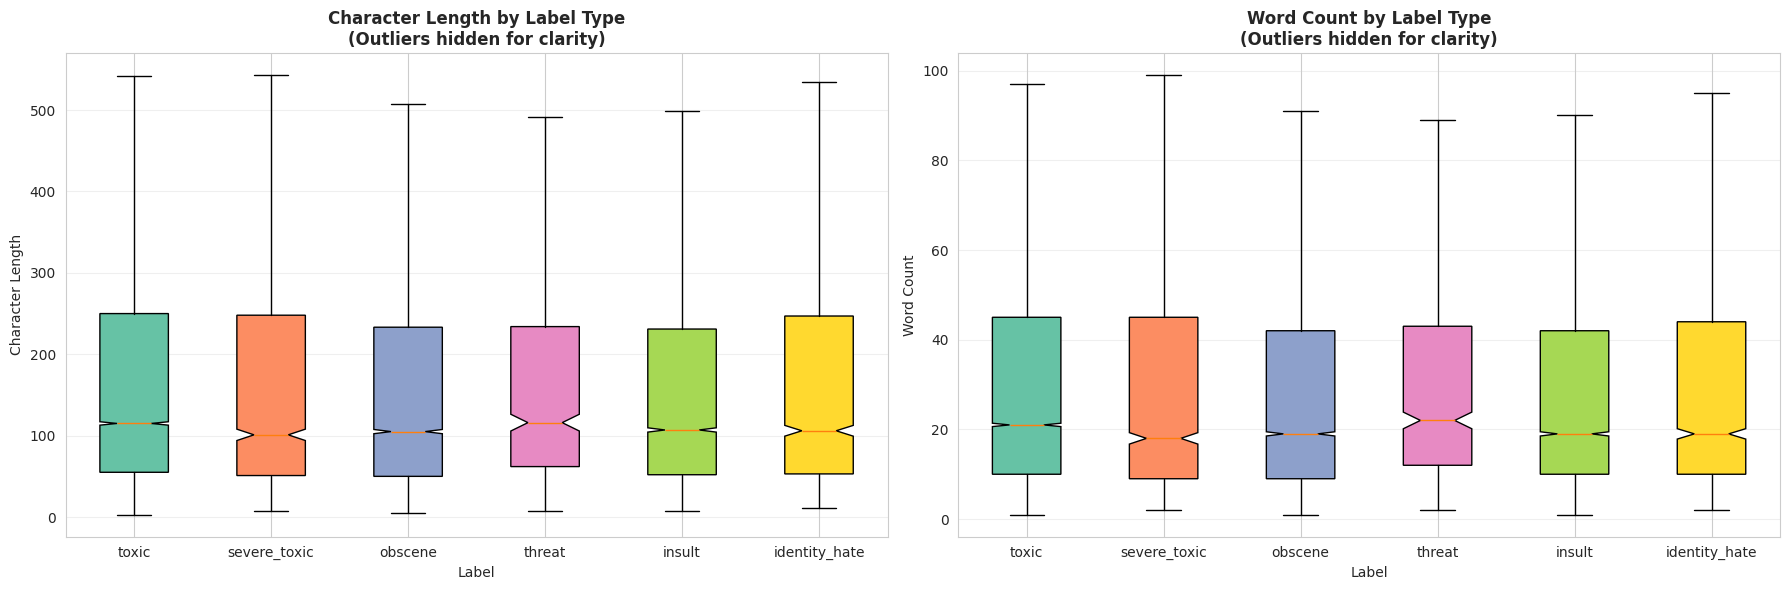

In [12]:
# ============================================================
# 6b. Boxplots — Character Length per Label Type
#     Shows median, IQR, and outliers for each toxicity category
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot: char_length for each of the 6 labels
box_data = []
box_labels = []
for col in label_cols:
    box_data.append(df.loc[df[col] == 1, 'char_length'].values)
    box_labels.append(col)

bp = axes[0].boxplot(box_data, labels=box_labels, patch_artist=True,
                     showfliers=False, notch=True)
colors_box = sns.color_palette('Set2', len(label_cols))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[0].set_title('Character Length by Label Type\n(Outliers hidden for clarity)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Character Length')
axes[0].set_xlabel('Label')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot: word_count for each of the 6 labels
box_data_w = [df.loc[df[col] == 1, 'word_count'].values for col in label_cols]

bp2 = axes[1].boxplot(box_data_w, labels=box_labels, patch_artist=True,
                      showfliers=False, notch=True)
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
axes[1].set_title('Word Count by Label Type\n(Outliers hidden for clarity)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Word Count')
axes[1].set_xlabel('Label')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

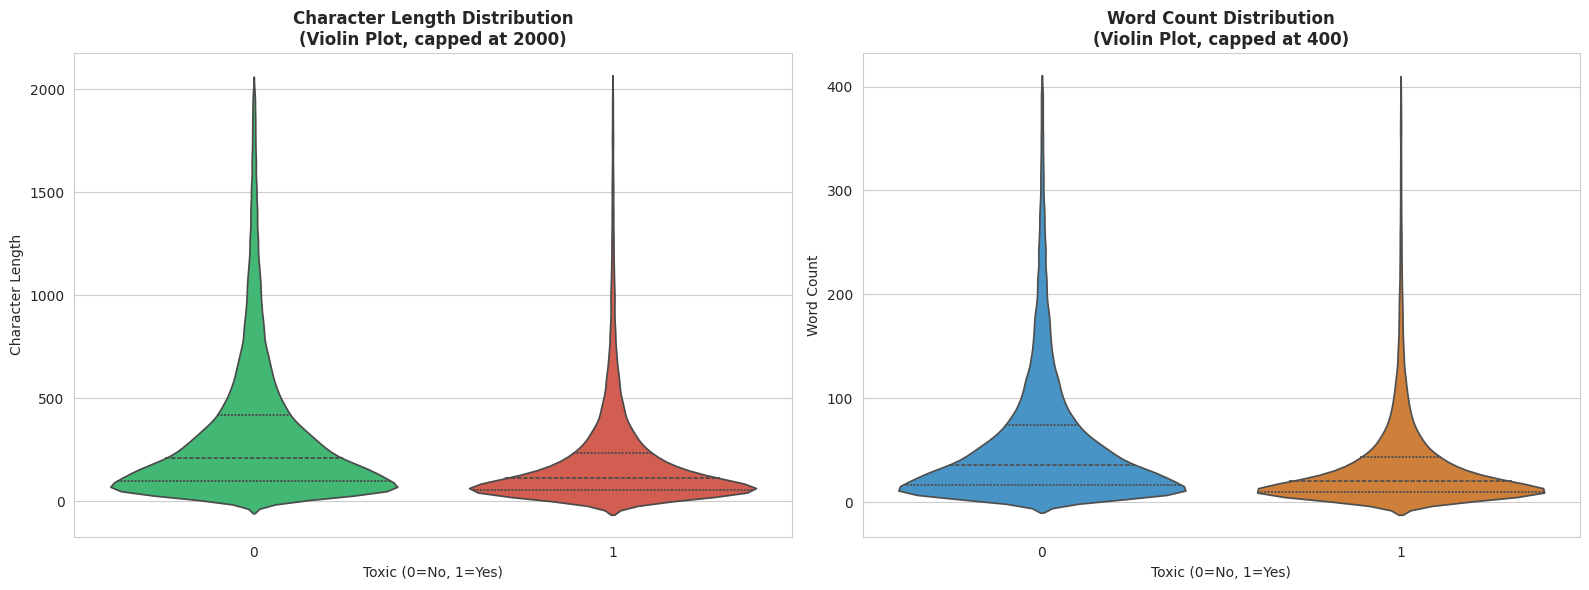

In [13]:
# ============================================================
# 6c. Violin Plots — Char Length & Word Count (Toxic vs Non-Toxic)
#     Shows the full probability density, not just quartiles
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin: char_length by toxic
# Cap at 2000 for visibility
plot_df = df[df['char_length'] <= 2000].copy()
sns.violinplot(x='toxic', y='char_length', data=plot_df, ax=axes[0],
               palette={'0': '#2ecc71', '1': '#e74c3c'}, inner='quartile')
axes[0].set_title('Character Length Distribution\n(Violin Plot, capped at 2000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Toxic (0=No, 1=Yes)')
axes[0].set_ylabel('Character Length')

# Violin: word_count by toxic
plot_df2 = df[df['word_count'] <= 400].copy()
sns.violinplot(x='toxic', y='word_count', data=plot_df2, ax=axes[1],
               palette={'0': '#3498db', '1': '#e67e22'}, inner='quartile')
axes[1].set_title('Word Count Distribution\n(Violin Plot, capped at 400)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Toxic (0=No, 1=Yes)')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

---
## 7. Writing Style Analysis

Explore how writing patterns differ between toxic and non-toxic comments: average word length (complexity), uppercase ratio (shouting/emphasis), punctuation usage, and vocabulary diversity.

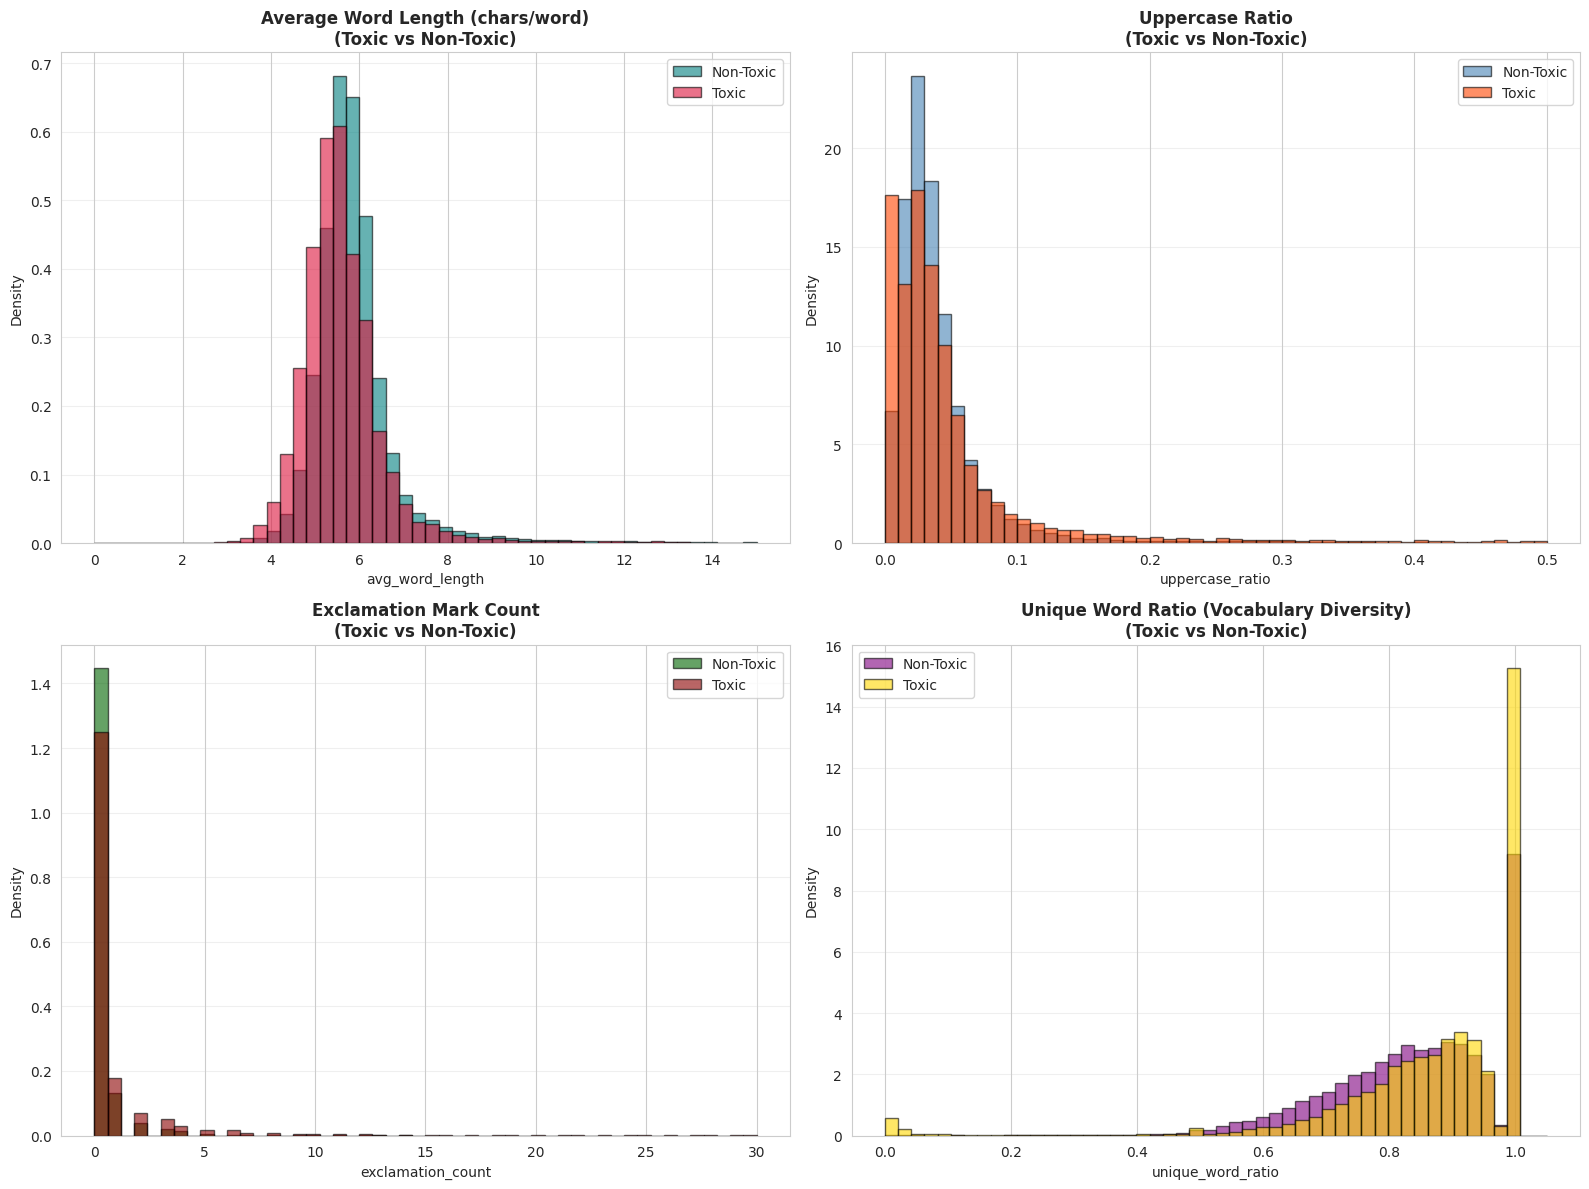

Writing Style Features — Mean by Toxicity:
toxic                   0       1
avg_word_length    5.9885  6.1373
uppercase_ratio    0.0456  0.1126
exclamation_count  0.4339  3.8835
unique_word_ratio  0.8406  0.8676


In [14]:
# ============================================================
# 7a. 4 Histograms — Writing Style Features (Toxic vs Non-Toxic)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

features = [
    ('avg_word_length', 'Average Word Length (chars/word)', (0, 15), 'teal', 'crimson'),
    ('uppercase_ratio', 'Uppercase Ratio', (0, 0.5), 'steelblue', 'orangered'),
    ('exclamation_count', 'Exclamation Mark Count', (0, 30), 'darkgreen', 'darkred'),
    ('unique_word_ratio', 'Unique Word Ratio (Vocabulary Diversity)', (0, 1.05), 'purple', 'gold'),
]

for ax, (col, title, rng, c_nt, c_t) in zip(axes.ravel(), features):
    ax.hist(df.loc[non_toxic_mask, col], bins=50, alpha=0.6, label='Non-Toxic',
            color=c_nt, edgecolor='black', range=rng, density=True)
    ax.hist(df.loc[toxic_mask, col], bins=50, alpha=0.6, label='Toxic',
            color=c_t, edgecolor='black', range=rng, density=True)
    ax.set_title(f'{title}\n(Toxic vs Non-Toxic)', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
style_cols = ['avg_word_length', 'uppercase_ratio', 'exclamation_count', 'unique_word_ratio']
print("Writing Style Features — Mean by Toxicity:")
print(df.groupby('toxic')[style_cols].mean().round(4).T)

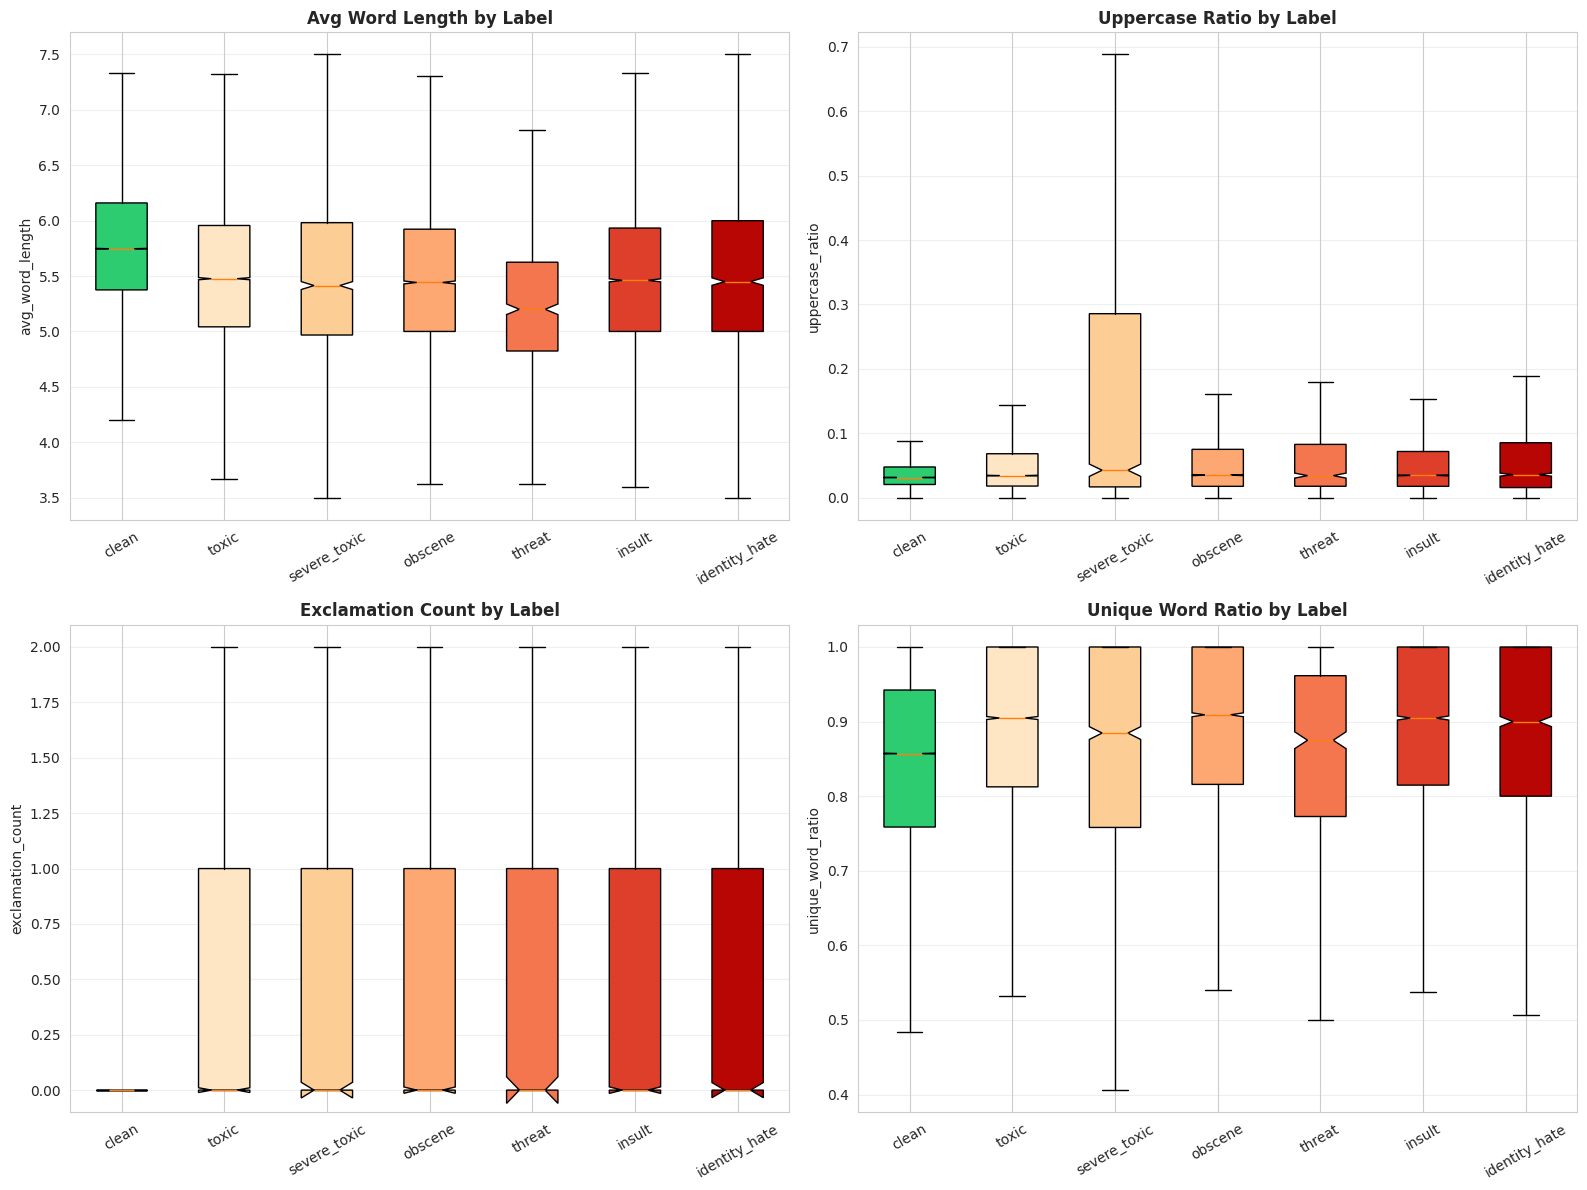

In [15]:
# ============================================================
# 7b. Boxplots — Writing Style Features across all 6 Labels
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

style_features = ['avg_word_length', 'uppercase_ratio', 'exclamation_count', 'unique_word_ratio']
style_titles = [
    'Avg Word Length by Label',
    'Uppercase Ratio by Label',
    'Exclamation Count by Label',
    'Unique Word Ratio by Label'
]

for ax, feat, title in zip(axes.ravel(), style_features, style_titles):
    box_data = [df.loc[df[col] == 1, feat].values for col in label_cols]
    # Add non-toxic baseline
    box_data.insert(0, df.loc[df['num_labels'] == 0, feat].values)
    box_names = ['clean'] + label_cols

    bp = ax.boxplot(box_data, labels=box_names, patch_artist=True,
                    showfliers=False, notch=True)
    palette = ['#2ecc71'] + list(sns.color_palette('OrRd', len(label_cols)))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Word Frequency & Bad Word Analysis

Examine the most common words in toxic vs non-toxic comments, the frequency of bad words, and how bad word count correlates with toxicity labels.

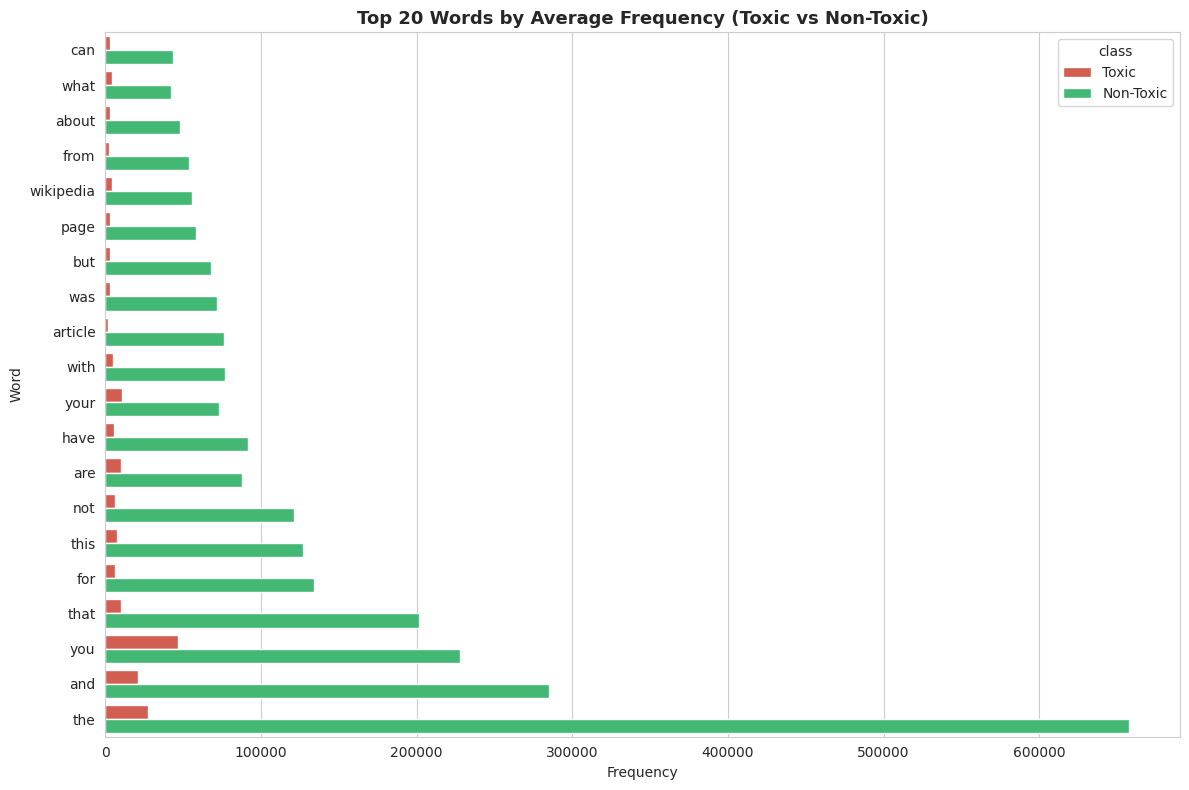

In [16]:
# ============================================================
# 8a. Top 20 Words — Toxic vs Non-Toxic (Horizontal Bar Chart)
# ============================================================

def tokenize(text):
    """Extract alphabetic tokens with length > 2."""
    tokens = re.findall(r"[a-zA-Z']+", str(text).lower())
    return [t for t in tokens if len(t) > 2]

# Count words in each class
toxic_counter = Counter(
    token for text in df.loc[toxic_mask, 'comment_text'].dropna()
    for token in tokenize(text)
)
non_toxic_counter = Counter(
    token for text in df.loc[non_toxic_mask, 'comment_text'].dropna()
    for token in tokenize(text)
)

# Build comparison dataframe using average frequency
all_vocab = set(toxic_counter) | set(non_toxic_counter)
word_df = pd.DataFrame({'word': list(all_vocab)})
word_df['toxic_count'] = word_df['word'].map(toxic_counter).fillna(0).astype(int)
word_df['non_toxic_count'] = word_df['word'].map(non_toxic_counter).fillna(0).astype(int)
word_df['mean_count'] = word_df[['toxic_count', 'non_toxic_count']].mean(axis=1)

top20 = word_df.nlargest(20, 'mean_count').sort_values('mean_count', ascending=True)

plot_long = top20.melt(id_vars='word', value_vars=['toxic_count', 'non_toxic_count'],
                       var_name='class', value_name='count')
plot_long['class'] = plot_long['class'].map({
    'toxic_count': 'Toxic', 'non_toxic_count': 'Non-Toxic'
})

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_long, x='count', y='word', hue='class',
            palette={'Toxic': '#e74c3c', 'Non-Toxic': '#2ecc71'})
plt.title('Top 20 Words by Average Frequency (Toxic vs Non-Toxic)', fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

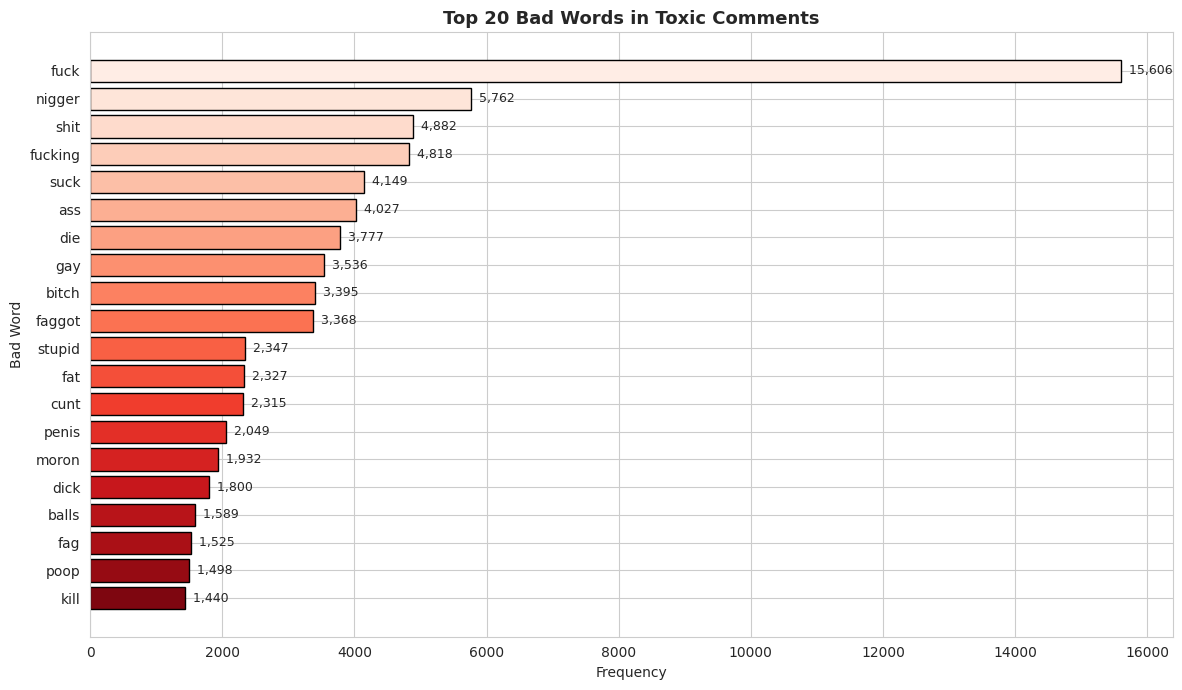

In [17]:
# ============================================================
# 8b. Top 20 Bad Words in Toxic Comments
# ============================================================

# Count bad words specifically in toxic comments
toxic_bad_counter = Counter(
    token for text in df.loc[toxic_mask, 'comment_text'].dropna()
    for token in tokenize(text) if token in bad_words
)

top20_bad = toxic_bad_counter.most_common(20)
bad_words_list = [w for w, _ in top20_bad]
bad_counts_list = [c for _, c in top20_bad]

plt.figure(figsize=(12, 7))
bars = plt.barh(bad_words_list[::-1], bad_counts_list[::-1],
                color=sns.color_palette('Reds_r', 20), edgecolor='black')
plt.title('Top 20 Bad Words in Toxic Comments', fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Bad Word')
for bar, val in zip(bars, bad_counts_list[::-1]):
    plt.text(val, bar.get_y() + bar.get_height()/2, f'  {val:,}',
             va='center', fontsize=9)
plt.tight_layout()
plt.show()

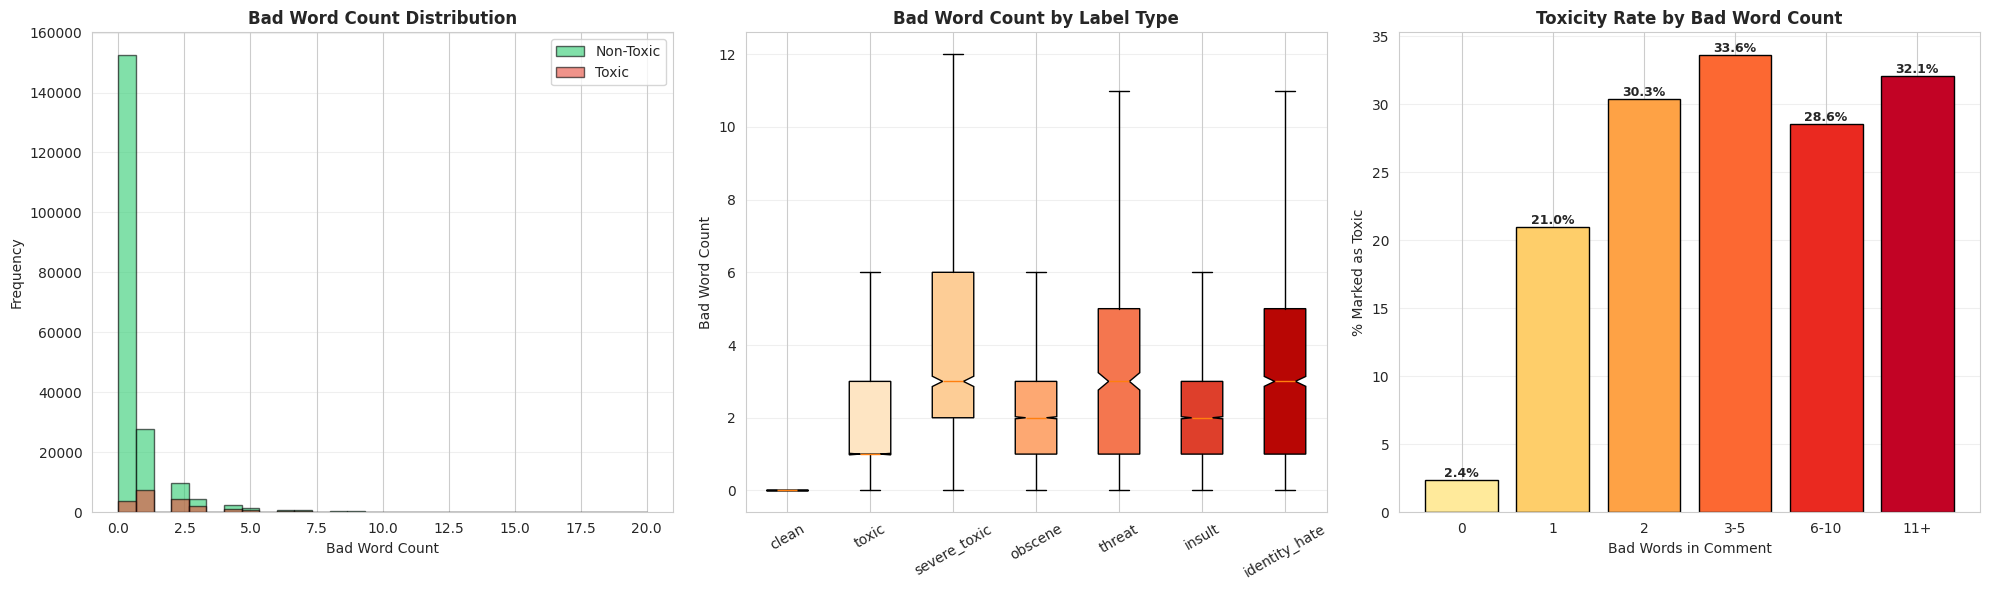

In [18]:
# ============================================================
# 8c. Bad Word Count Distribution & its Relationship with Labels
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram: bad_word_count (Toxic vs Non-Toxic)
axes[0].hist(df.loc[non_toxic_mask, 'bad_word_count'], bins=30, alpha=0.6,
             label='Non-Toxic', color='#2ecc71', edgecolor='black', range=(0, 20))
axes[0].hist(df.loc[toxic_mask, 'bad_word_count'], bins=30, alpha=0.6,
             label='Toxic', color='#e74c3c', edgecolor='black', range=(0, 20))
axes[0].set_title('Bad Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bad Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot: bad_word_count per label
box_data = [df.loc[df[col] == 1, 'bad_word_count'].values for col in label_cols]
box_data.insert(0, df.loc[df['num_labels'] == 0, 'bad_word_count'].values)
box_names = ['clean'] + label_cols

bp = axes[1].boxplot(box_data, labels=box_names, patch_artist=True,
                     showfliers=False, notch=True)
palette = ['#2ecc71'] + list(sns.color_palette('OrRd', len(label_cols)))
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c)
axes[1].set_title('Bad Word Count by Label Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bad Word Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Toxicity rate by bad_word_count bucket
df['bad_word_bucket'] = pd.cut(df['bad_word_count'], bins=[-1, 0, 1, 2, 5, 10, 100],
                               labels=['0', '1', '2', '3-5', '6-10', '11+'])
toxic_rate = df.groupby('bad_word_bucket', observed=True)['toxic'].mean() * 100

axes[2].bar(toxic_rate.index.astype(str), toxic_rate.values,
            color=sns.color_palette('YlOrRd', len(toxic_rate)), edgecolor='black')
axes[2].set_title('Toxicity Rate by Bad Word Count', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Bad Words in Comment')
axes[2].set_ylabel('% Marked as Toxic')
for i, (idx, val) in enumerate(toxic_rate.items()):
    axes[2].text(i, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop(columns=['bad_word_bucket'], inplace=True)

### 8d. Ratio of Used Bad Words — Toxic vs Non-Toxic

Compare the **bad-word ratio** (bad words / total words) between `toxic=1` and `toxic=0` comments. This metric normalises for comment length and reveals how "concentrated" profanity is in each group.

Bad-Word Ratio  (bad words / total words)
Metric                      Toxic    Non-Toxic
--------------------------------------------------
Mean                       0.1139       0.0095
Median                     0.0714       0.0000
Std                        0.3877       0.0306
Max                       53.2000       1.0000
% with any bad word         82.6%        24.6%


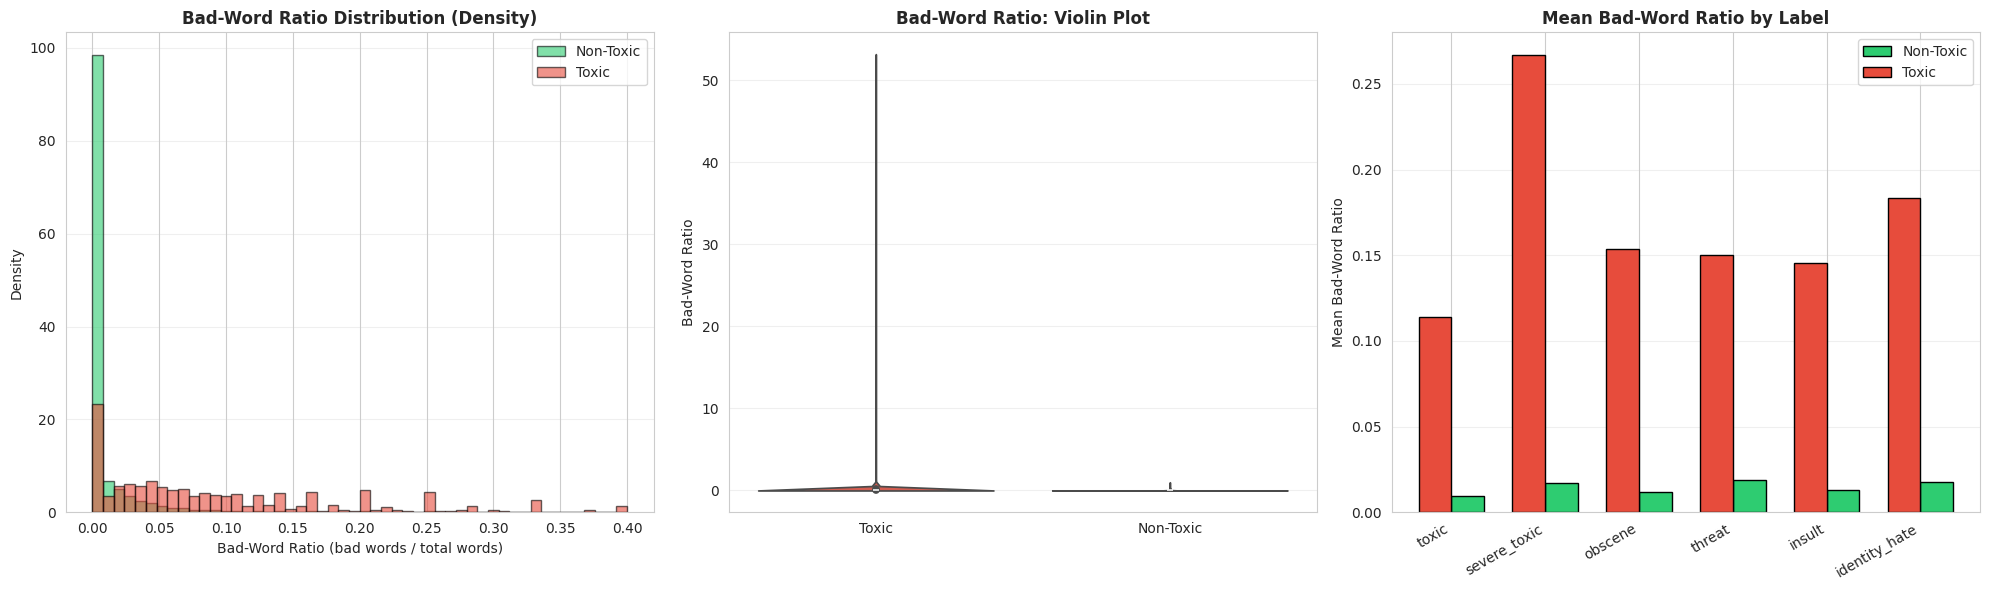


Mean Bad-Word Ratio per Label (positive vs negative):
        Label  Positive (=1)  Negative (=0)  Ratio (pos/neg)
        toxic         0.1139         0.0095          11.9898
 severe_toxic         0.2667         0.0173          15.4209
      obscene         0.1536         0.0118          13.0362
       threat         0.1501         0.0191           7.8673
       insult         0.1455         0.0128          11.3949
identity_hate         0.1832         0.0179          10.2242


In [19]:
# ============================================================
# 8d. Bad-Word Ratio (bad_word_count / word_count) — Toxic vs Non-Toxic
# ============================================================

# Compute ratio (avoid division by zero)
df['bad_word_ratio'] = df['bad_word_count'] / df['word_count'].replace(0, 1)

# --- Summary statistics ---
ratio_toxic     = df.loc[toxic_mask, 'bad_word_ratio']
ratio_non_toxic = df.loc[non_toxic_mask, 'bad_word_ratio']

print("Bad-Word Ratio  (bad words / total words)")
print("=" * 50)
print(f"{'Metric':<22} {'Toxic':>10} {'Non-Toxic':>12}")
print("-" * 50)
print(f"{'Mean':<22} {ratio_toxic.mean():>10.4f} {ratio_non_toxic.mean():>12.4f}")
print(f"{'Median':<22} {ratio_toxic.median():>10.4f} {ratio_non_toxic.median():>12.4f}")
print(f"{'Std':<22} {ratio_toxic.std():>10.4f} {ratio_non_toxic.std():>12.4f}")
print(f"{'Max':<22} {ratio_toxic.max():>10.4f} {ratio_non_toxic.max():>12.4f}")
print(f"{'% with any bad word':<22} {(ratio_toxic > 0).mean()*100:>9.1f}% {(ratio_non_toxic > 0).mean()*100:>11.1f}%")

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (A) Overlapping histograms
axes[0].hist(ratio_non_toxic, bins=50, range=(0, 0.4), alpha=0.6,
             color='#2ecc71', edgecolor='black', label='Non-Toxic', density=True)
axes[0].hist(ratio_toxic, bins=50, range=(0, 0.4), alpha=0.6,
             color='#e74c3c', edgecolor='black', label='Toxic', density=True)
axes[0].set_title('Bad-Word Ratio Distribution (Density)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bad-Word Ratio (bad words / total words)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# (B) Violin + box plot comparison
violin_data = pd.DataFrame({
    'bad_word_ratio': pd.concat([ratio_toxic, ratio_non_toxic]),
    'toxic': ['Toxic'] * len(ratio_toxic) + ['Non-Toxic'] * len(ratio_non_toxic)
})
sns.violinplot(data=violin_data, x='toxic', y='bad_word_ratio',
               palette={'Toxic': '#e74c3c', 'Non-Toxic': '#2ecc71'},
               inner='box', cut=0, ax=axes[1])
axes[1].set_title('Bad-Word Ratio: Violin Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Bad-Word Ratio')
axes[1].grid(axis='y', alpha=0.3)

# (C) Mean bad-word ratio across all 6 label categories
mean_ratios = {}
for col in label_cols:
    mean_ratios[col + '=1'] = df.loc[df[col] == 1, 'bad_word_ratio'].mean()
    mean_ratios[col + '=0'] = df.loc[df[col] == 0, 'bad_word_ratio'].mean()

ratio_df = pd.DataFrame({
    'Label': label_cols,
    'Positive (=1)': [mean_ratios[c + '=1'] for c in label_cols],
    'Negative (=0)': [mean_ratios[c + '=0'] for c in label_cols],
})
ratio_df['Ratio (pos/neg)'] = ratio_df['Positive (=1)'] / ratio_df['Negative (=0)'].replace(0, np.nan)

x = np.arange(len(label_cols))
w = 0.35
axes[2].bar(x + w/2, ratio_df['Negative (=0)'], w, label='Non-Toxic',
            color='#2ecc71', edgecolor='black')
axes[2].bar(x - w/2, ratio_df['Positive (=1)'], w, label='Toxic',
            color='#e74c3c', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(label_cols, rotation=30, ha='right')
axes[2].set_title('Mean Bad-Word Ratio by Label', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Mean Bad-Word Ratio')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the summary table
print("\nMean Bad-Word Ratio per Label (positive vs negative):")
print(ratio_df.to_string(index=False, float_format='{:.4f}'.format))

# Clean up temporary column
df.drop(columns=['bad_word_ratio'], inplace=True)

---
## 9. Outlier Detection

Identify extreme values in text length features using IQR fences and percentile curves. Understanding outliers is crucial for deciding preprocessing strategies (e.g., truncation length).

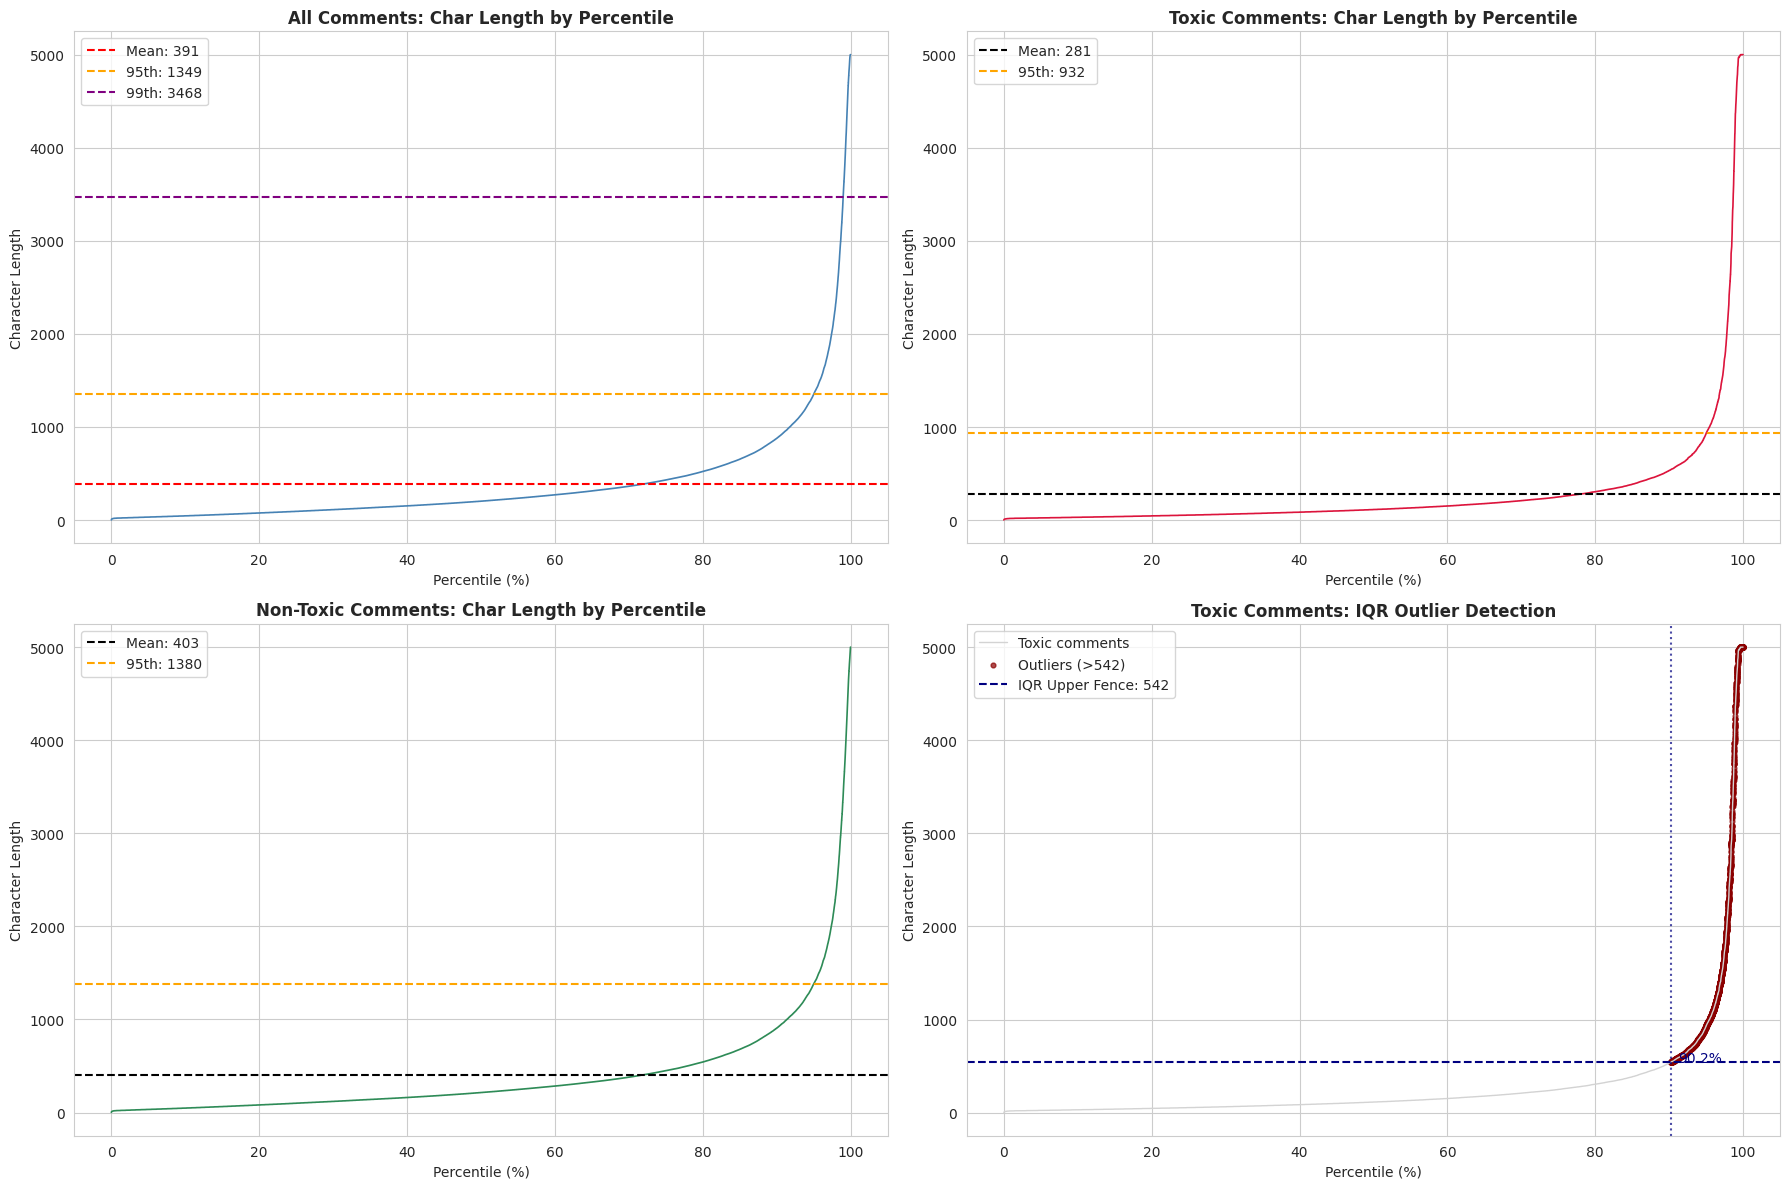

IQR Upper Fence (Toxic): 542 chars
Outliers above fence: 2,092 comments (9.8% of toxic)


In [20]:
# ============================================================
# 9a. Percentile Curves — Character Length (Overall, Toxic, Non-Toxic)
#     Shows how text length accumulates across the dataset
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Helper to create sorted percentile data
def percentile_data(series):
    s = series.sort_values().reset_index(drop=True)
    pct = (s.index + 1) / len(s) * 100
    return pct, s

# --- A) Overall ---
pct_all, val_all = percentile_data(df['char_length'])
axes[0, 0].plot(pct_all, val_all, linewidth=1.2, color='steelblue')
mean_all = df['char_length'].mean()
p95_all = df['char_length'].quantile(0.95)
p99_all = df['char_length'].quantile(0.99)
axes[0, 0].axhline(mean_all, color='red', ls='--', label=f'Mean: {mean_all:.0f}')
axes[0, 0].axhline(p95_all, color='orange', ls='--', label=f'95th: {p95_all:.0f}')
axes[0, 0].axhline(p99_all, color='purple', ls='--', label=f'99th: {p99_all:.0f}')
axes[0, 0].set_title('All Comments: Char Length by Percentile', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Percentile (%)')
axes[0, 0].set_ylabel('Character Length')
axes[0, 0].legend()

# --- B) Toxic ---
pct_t, val_t = percentile_data(df.loc[toxic_mask, 'char_length'])
t_mean = df.loc[toxic_mask, 'char_length'].mean()
t_p95 = df.loc[toxic_mask, 'char_length'].quantile(0.95)
axes[0, 1].plot(pct_t, val_t, linewidth=1.2, color='crimson')
axes[0, 1].axhline(t_mean, color='black', ls='--', label=f'Mean: {t_mean:.0f}')
axes[0, 1].axhline(t_p95, color='orange', ls='--', label=f'95th: {t_p95:.0f}')
axes[0, 1].set_title('Toxic Comments: Char Length by Percentile', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Percentile (%)')
axes[0, 1].set_ylabel('Character Length')
axes[0, 1].legend()

# --- C) Non-Toxic ---
pct_nt, val_nt = percentile_data(df.loc[non_toxic_mask, 'char_length'])
nt_mean = df.loc[non_toxic_mask, 'char_length'].mean()
nt_p95 = df.loc[non_toxic_mask, 'char_length'].quantile(0.95)
axes[1, 0].plot(pct_nt, val_nt, linewidth=1.2, color='seagreen')
axes[1, 0].axhline(nt_mean, color='black', ls='--', label=f'Mean: {nt_mean:.0f}')
axes[1, 0].axhline(nt_p95, color='orange', ls='--', label=f'95th: {nt_p95:.0f}')
axes[1, 0].set_title('Non-Toxic Comments: Char Length by Percentile', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Percentile (%)')
axes[1, 0].set_ylabel('Character Length')
axes[1, 0].legend()

# --- D) IQR Outlier Scatter for Toxic comments ---
q1 = df.loc[toxic_mask, 'char_length'].quantile(0.25)
q3 = df.loc[toxic_mask, 'char_length'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

axes[1, 1].plot(pct_t, val_t, color='lightgray', linewidth=1.0, label='Toxic comments')
outlier_idx = val_t > upper_fence
axes[1, 1].scatter(pct_t[outlier_idx], val_t[outlier_idx], s=12, color='darkred',
                   alpha=0.7, label=f'Outliers (>{upper_fence:.0f})')
axes[1, 1].axhline(upper_fence, color='navy', ls='--', label=f'IQR Upper Fence: {upper_fence:.0f}')
fence_pct = (val_t <= upper_fence).sum() / len(val_t) * 100
axes[1, 1].axvline(fence_pct, color='navy', ls=':', alpha=0.7)
axes[1, 1].text(fence_pct + 1, upper_fence, f'{fence_pct:.1f}%', color='navy', fontsize=10)
axes[1, 1].set_title('Toxic Comments: IQR Outlier Detection', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Percentile (%)')
axes[1, 1].set_ylabel('Character Length')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Key stats
print(f"IQR Upper Fence (Toxic): {upper_fence:.0f} chars")
print(f"Outliers above fence: {outlier_idx.sum():,} comments ({outlier_idx.sum()/toxic_mask.sum()*100:.1f}% of toxic)")

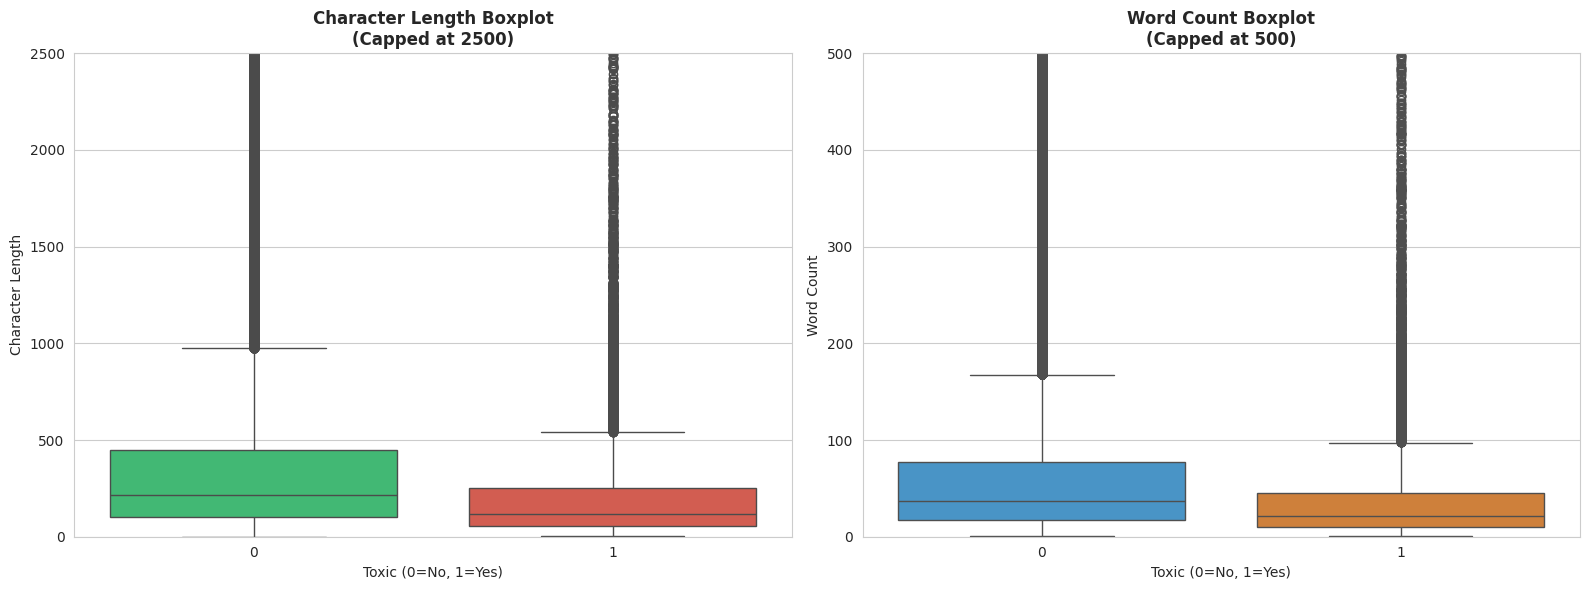

In [21]:
# ============================================================
# 9b. Boxplot with Outliers — All Numeric Features Side by Side
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: char_length by toxic (with outlier fliers visible, y-capped)
sns.boxplot(x='toxic', y='char_length', data=df, ax=axes[0],
            palette={'0': '#2ecc71', '1': '#e74c3c'})
axes[0].set_ylim(0, 2500)
axes[0].set_title('Character Length Boxplot\n(Capped at 2500)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Toxic (0=No, 1=Yes)')
axes[0].set_ylabel('Character Length')

# Boxplot: word_count by toxic
sns.boxplot(x='toxic', y='word_count', data=df, ax=axes[1],
            palette={'0': '#3498db', '1': '#e67e22'})
axes[1].set_ylim(0, 500)
axes[1].set_title('Word Count Boxplot\n(Capped at 500)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Toxic (0=No, 1=Yes)')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

---
## 10. Label Inconsistency Analysis

Some comments are labeled as `severe_toxic`, `obscene`, `threat`, `insult`, or `identity_hate` but **not** as `toxic`. This is logically inconsistent — a threatening comment should inherently be toxic. Understanding these edge cases helps decide whether to clean them.

Label Inconsistencies (sub-label=1 but toxic=0):
     severe_toxic: 0 inconsistent out of 1,962 total (0.0%)
          obscene: 588 inconsistent out of 12,140 total (4.8%)
           threat: 35 inconsistent out of 689 total (5.1%)
           insult: 618 inconsistent out of 11,304 total (5.5%)
    identity_hate: 122 inconsistent out of 2,117 total (5.8%)


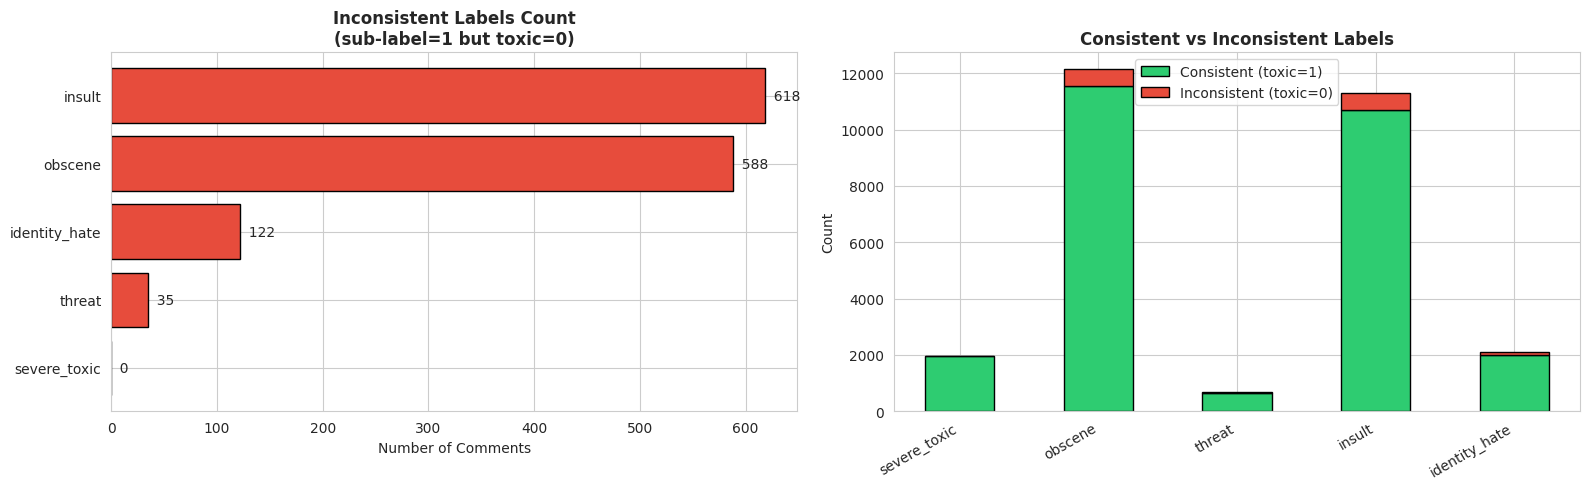


Total inconsistent records: 1,363

Sample comments that are 'threat=1' but 'toxic=0':
  [1] Please stop. If you continue to ignore our policies by introducing inappropriate pages to Wikipedia, you will be blocked....
  [2] "

 Lock Down 

I don't know about the ""Bulgarian BULLSHIT season"", but don't be fooled from where exactly i connect. If i see you editing, or someo...
  [3] That's funny. You was personally offended? So the bad things writer new you, your name etc, right? 
And one get offended by a comment, or epithets on ...


In [22]:
# ============================================================
# 10a. Find comments with sub-labels but toxic=0
# ============================================================

sub_labels = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
inconsistency_counts = {}

print("Label Inconsistencies (sub-label=1 but toxic=0):")
print("=" * 60)

for col in sub_labels:
    mask_inc = (df[col] == 1) & (df['toxic'] == 0)
    count = mask_inc.sum()
    inconsistency_counts[col] = count
    total_col = df[col].sum()
    pct = (count / total_col * 100) if total_col > 0 else 0
    print(f"  {col:>15s}: {count:,} inconsistent out of {total_col:,} total ({pct:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of inconsistencies
inc_df = pd.DataFrame({
    'label': list(inconsistency_counts.keys()),
    'count': list(inconsistency_counts.values())
}).sort_values('count', ascending=True)

axes[0].barh(inc_df['label'], inc_df['count'], color='#e74c3c', edgecolor='black')
axes[0].set_title('Inconsistent Labels Count\n(sub-label=1 but toxic=0)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Comments')
for i, (_, row) in enumerate(inc_df.iterrows()):
    axes[0].text(row['count'], i, f'  {row["count"]:,}', va='center', fontsize=10)

# Stacked bar: consistent vs inconsistent per sub-label
consistent = {col: df[col].sum() - inconsistency_counts[col] for col in sub_labels}
x = np.arange(len(sub_labels))
w = 0.5
axes[1].bar(x, [consistent[c] for c in sub_labels], w, label='Consistent (toxic=1)', color='#2ecc71', edgecolor='black')
axes[1].bar(x, [inconsistency_counts[c] for c in sub_labels], w,
            bottom=[consistent[c] for c in sub_labels],
            label='Inconsistent (toxic=0)', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sub_labels, rotation=30, ha='right')
axes[1].set_title('Consistent vs Inconsistent Labels', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show sample inconsistent comments
total_inconsistent = sum(inconsistency_counts.values())
print(f"\nTotal inconsistent records: {total_inconsistent:,}")
print("\nSample comments that are 'threat=1' but 'toxic=0':")
threat_not_toxic = df[(df['threat'] == 1) & (df['toxic'] == 0)]
if len(threat_not_toxic) > 0:
    for i, text in enumerate(threat_not_toxic['comment_text'].head(3).values):
        print(f"  [{i+1}] {text[:150]}...")

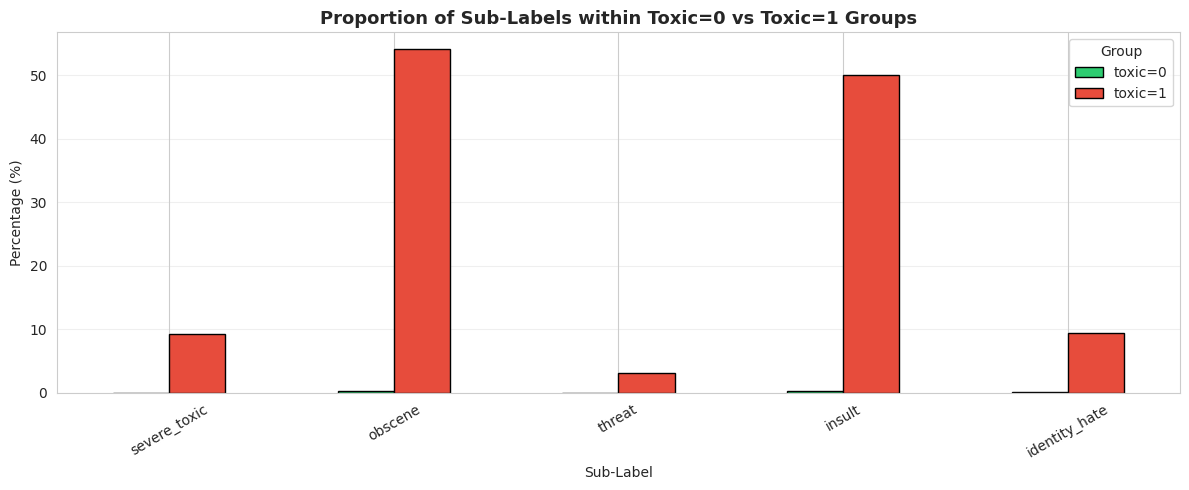


Percentage of comments in each group that have each sub-label:
toxic             0      1
severe_toxic   0.00   9.18
obscene        0.29  54.02
threat         0.02   3.06
insult         0.31  49.97
identity_hate  0.06   9.33


In [23]:
# ============================================================
# 10b. Grouped summary: Label proportions when toxic=1 vs toxic=0
#      Shows which sub-labels co-occur with toxic
# ============================================================

summary = df.groupby('toxic')[sub_labels].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
summary.T.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Proportion of Sub-Labels within Toxic=0 vs Toxic=1 Groups', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Sub-Label')
ax.legend(['toxic=0', 'toxic=1'], title='Group')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPercentage of comments in each group that have each sub-label:")
print(summary.round(2).T)

---
## 11. EDA Conclusions

### Key Findings

1. **Class Imbalance**: The dataset is heavily skewed toward non-toxic comments. The `toxic` label has the highest positive rate among all labels, while `threat` and `identity_hate` are extremely rare. This imbalance must be addressed during modeling (e.g., oversampling, class weights).

2. **Multi-Label Nature**: Most flagged comments carry multiple toxicity labels simultaneously. `obscene` and `insult` frequently co-occur with `toxic`, while `threat` tends to be more isolated.

3. **Label Correlations**: Strong correlations exist between `toxic`↔`obscene`, `toxic`↔`insult`, and `obscene`↔`insult`. The `threat` label is the least correlated with other labels.

4. **Text Length Patterns**: Toxic comments tend to have different length distributions than non-toxic ones. The length features (`char_length`, `word_count`) can serve as useful baseline features.

5. **Writing Style Differences**: Toxic comments show higher uppercase ratios (shouting), more exclamation marks, and potentially different vocabulary diversity compared to non-toxic comments.

6. **Bad Words as Features**: The presence and count of bad words is a strong predictor of toxicity. Comments with more bad words have drastically higher toxicity rates.

7. **Label Inconsistencies**: A small number of comments have sub-labels (e.g., threat, insult) active but `toxic=0`. These may be labeling errors and should be considered for correction.

8. **Outliers**: Character length has a long right tail with extreme outliers. Setting a truncation threshold at the 95th-99th percentile (or IQR upper fence) is recommended for model input.

### Recommendations for Modeling
- Use `toxic` as the primary target variable (highest positive sample count)
- Consider fixing label inconsistencies before training
- Apply text truncation based on the 95th percentile
- Use engineered features (bad_word_count, uppercase_ratio, etc.) alongside text embeddings
- Address class imbalance with appropriate sampling or loss function strategies